(960, 13) (240, 13)

Linear Regression
RMSE: 27.12145116489062
MAE: 21.052926674588395

Random Forest
RMSE: 31.660007317329118
MAE: 24.87391666666667


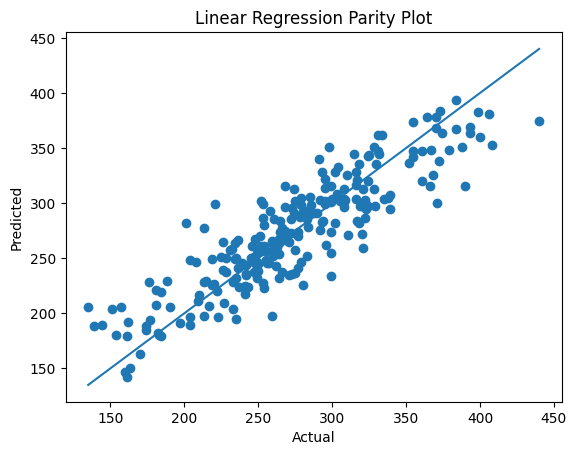

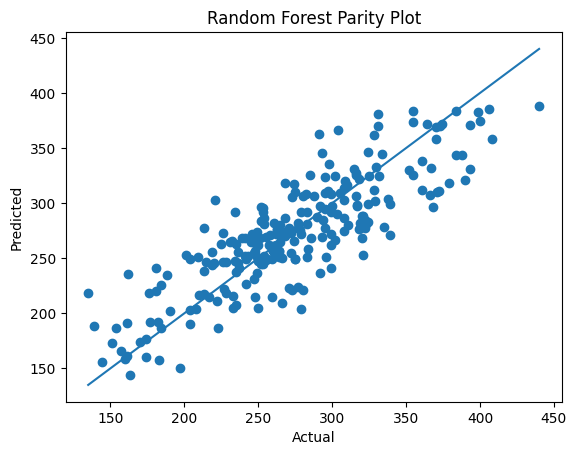

                     feature  importance
7      cat__store_size_small    0.183954
10          num__is_festival    0.174477
5   cat__location_type_urban    0.140498
14          num__day_of_week    0.090612
9            num__is_weekend    0.063547


In [4]:
# 1. Date Feature Engineering

import pandas as pd

# Load data
df = pd.read_csv(r"C:\Users\yasmi\OneDrive\Documents\ml-assessment-yasminbano-khan\data\q3_retail_promotions.csv")

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month end flag
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Show sample
df.head()

# 2. Temporal Train-Test Split

# Sort by date
df = df.sort_values(by='transaction_date')

# Split index
split_index = int(0.8 * len(df))

train = df.iloc[:split_index]
test = df.iloc[split_index:]

print(train.shape, test.shape)

# 3. Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Features & target
X_train = train.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test['items_sold']

# Categorical & numerical columns
cat_cols = ['promotion_type', 'location_type', 'store_size']
num_cols = [col for col in X_train.columns if col not in cat_cols]

# Transformer
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# 4. Model Training and Evaluation

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Pipelines
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Train
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Predict
lr_pred = lr_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

# Metrics
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)

evaluate("Linear Regression", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)

# Parity Plot

import matplotlib.pyplot as plt

# Linear Regression plot
plt.scatter(y_test, lr_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Linear Regression Parity Plot")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# Random Forest plot
plt.scatter(y_test, rf_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Random Forest Parity Plot")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# Get feature names after encoding
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Importances
importances = rf_pipeline.named_steps['model'].feature_importances_

# DataFrame
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_imp.head(5))

1. Pulled year, month and day from the transaction date to capture temporal patterns. Created a binary feature is_month_end to identify periods where sales may increase near the end of the month.
2. A random split is inappropriate for time-series data because it can mix past and future information. This leads to data leakage.
3. The Random Forest model shows that the most important features are store size (small), festival indicator, urban location type, day of week, and weekend indicator. These features have the highest influence on predicting items sold.